In [1]:
import rioxarray
import xarray
import rioxarray
import matplotlib.pyplot as plt
import numpy as np
import scipy
import matplotlib

In [2]:
prefix = '/scratch/sentinel2_arctic/'
region = 'fairbanks'

In [3]:
path = f'{prefix}/{region}_results.zarr'
ds = xarray.open_zarr(path, mask_and_scale=True, consolidated=False)

path = f'{prefix}/{region}_cloudmask.zarr'
cloudmask = xarray.open_zarr(path, consolidated=False)['cloudmask']

path = f'{prefix}/{region}_sharp.zarr'
rgb = xarray.open_zarr(path, consolidated=False)['reflectance'].sel(band=['B4', 'B3', 'B2'])

In [4]:
path = f'{prefix}/{region}_sharp.zarr'
spatial_ref = xarray.open_zarr(path, mask_and_scale=True, consolidated=False)['spatial_ref']

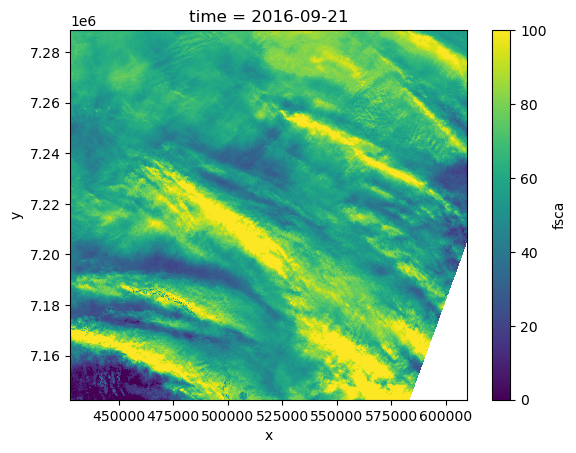

In [5]:
ds['fsca'].isel(time=20).coarsen(x=10, y=10, boundary='trim').mean().plot()

In [6]:
ds['cloudmask'] = cloudmask
ds['rgb'] = rgb

# Interpolating clouds and sharpening artifacts

- sharpening occasionally leaves holes. Probably N/A related

In [7]:
from dask.distributed import LocalCluster
import dask.distributed
import logging

dask.config.set({'temporary-directory': '/data/dask'})
dask.config.set({'distributed.comm.timeouts.tcp': '1200s'})
dask.config.set({'distributed.comm.timeouts.connect': '1200s'})
dask.config.get('distributed.comm.timeouts')

cluster = dask.distributed.LocalCluster(n_workers=8, 
                                        threads_per_worker=2, # Good question ... 
                                        memory_limit='128GB', 
                                        processes=True,  # Probably a good idea here
                                        dashboard_address='localhost:8787',
                                        silence_logs=logging.ERROR)

client = dask.distributed.Client(cluster) 

In [8]:
cloudmasked = xarray.where(ds['cloudmask']==0, ds[['fsca', 'fshade', 'grain_size', 'dust_concentration', 'rgb']], np.nan)
#cloudmasked = xarray.where(ds['cloudmask']==0, ds[['fsca', 'fshade']], np.nan)

In [9]:
cloudmasked['spatial_ref'] = spatial_ref

## scipy:
`method` Specifies the kind of interpolation as a string or as an integer specifying the order of the spline interpolator to use. The string has to be one of ‘linear’, ‘nearest’, ‘nearest-up’, ‘zero’, ‘slinear’, ‘quadratic’, ‘cubic’, ‘previous’, or ‘next’. ‘zero’, ‘slinear’, ‘quadratic’ and ‘cubic’ refer to a spline interpolation of zeroth, first, second or third order; ‘previous’ and ‘next’ simply return the previous or next value of the point; ‘nearest-up’ and ‘nearest’ differ when interpolating half-integers (e.g. 0.5, 1.5) in that ‘nearest-up’ rounds up and ‘nearest’ rounds down. Default is ‘linear’.

In [10]:
chunks_x = ds.chunks['x']
chunks_y = ds.chunks['y']
cloudmasked = cloudmasked.chunk(time=-1, y=chunks_y, x=chunks_x)

In [11]:
%%time
import datetime
max_gap = datetime.timedelta(days=14)
cloud_filled = cloudmasked.interpolate_na(dim="time", method="linear", max_gap=max_gap)

CPU times: user 212 ms, sys: 27 ms, total: 239 ms
Wall time: 227 ms


/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(
/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(
/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(
/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(
/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/dask/array/core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


In [12]:
cloud_filled = cloud_filled.chunk(time=1, y=chunks_y, x=chunks_x)

In [13]:
cloud_filled

<xarray.Dataset> Size: 3TB
Dimensions:             (y: 14628, time: 463, x: 18208, band: 3)
Coordinates:
  * y                   (y) float64 117kB 7.289e+06 7.289e+06 ... 7.142e+06
  * time                (time) datetime64[ns] 4kB 2015-10-22 ... 2025-03-13
  * x                   (x) float64 146kB 4.277e+05 4.277e+05 ... 6.098e+05
  * band                (band) object 24B 'B4' 'B3' 'B2'
Data variables:
    fsca                (time, y, x) float32 493GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    fshade              (time, y, x) float32 493GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    grain_size          (time, y, x) float32 493GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    dust_concentration  (time, y, x) float32 493GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    rgb                 (time, y, x, band) float32 1TB dask.array<chunksize=(1, 1219, 1138, 3), meta=np.ndarray>
    spatial_ref         int64 8B ...

# Plot

In [14]:
colors = [
    (0, 0, 0, 0),        # Clear -> transparent
    (0xfd/255, 0xe0/255, 0xdd/255, 0.6),  # Thick Cloud
    (0xfa/255, 0x9f/255, 0xb5/255, 0.6),  # Thin Cloud
    (0xc5/255, 0x1b/255, 0x8a/255, 0.6)   # Cloud Shadow
]
cmap = matplotlib.colors.ListedColormap(colors)
norm = matplotlib.colors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=len(colors))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2076124].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2076124].
/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 27.60 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1977046].


2018-08-07T00:00:00.000000000


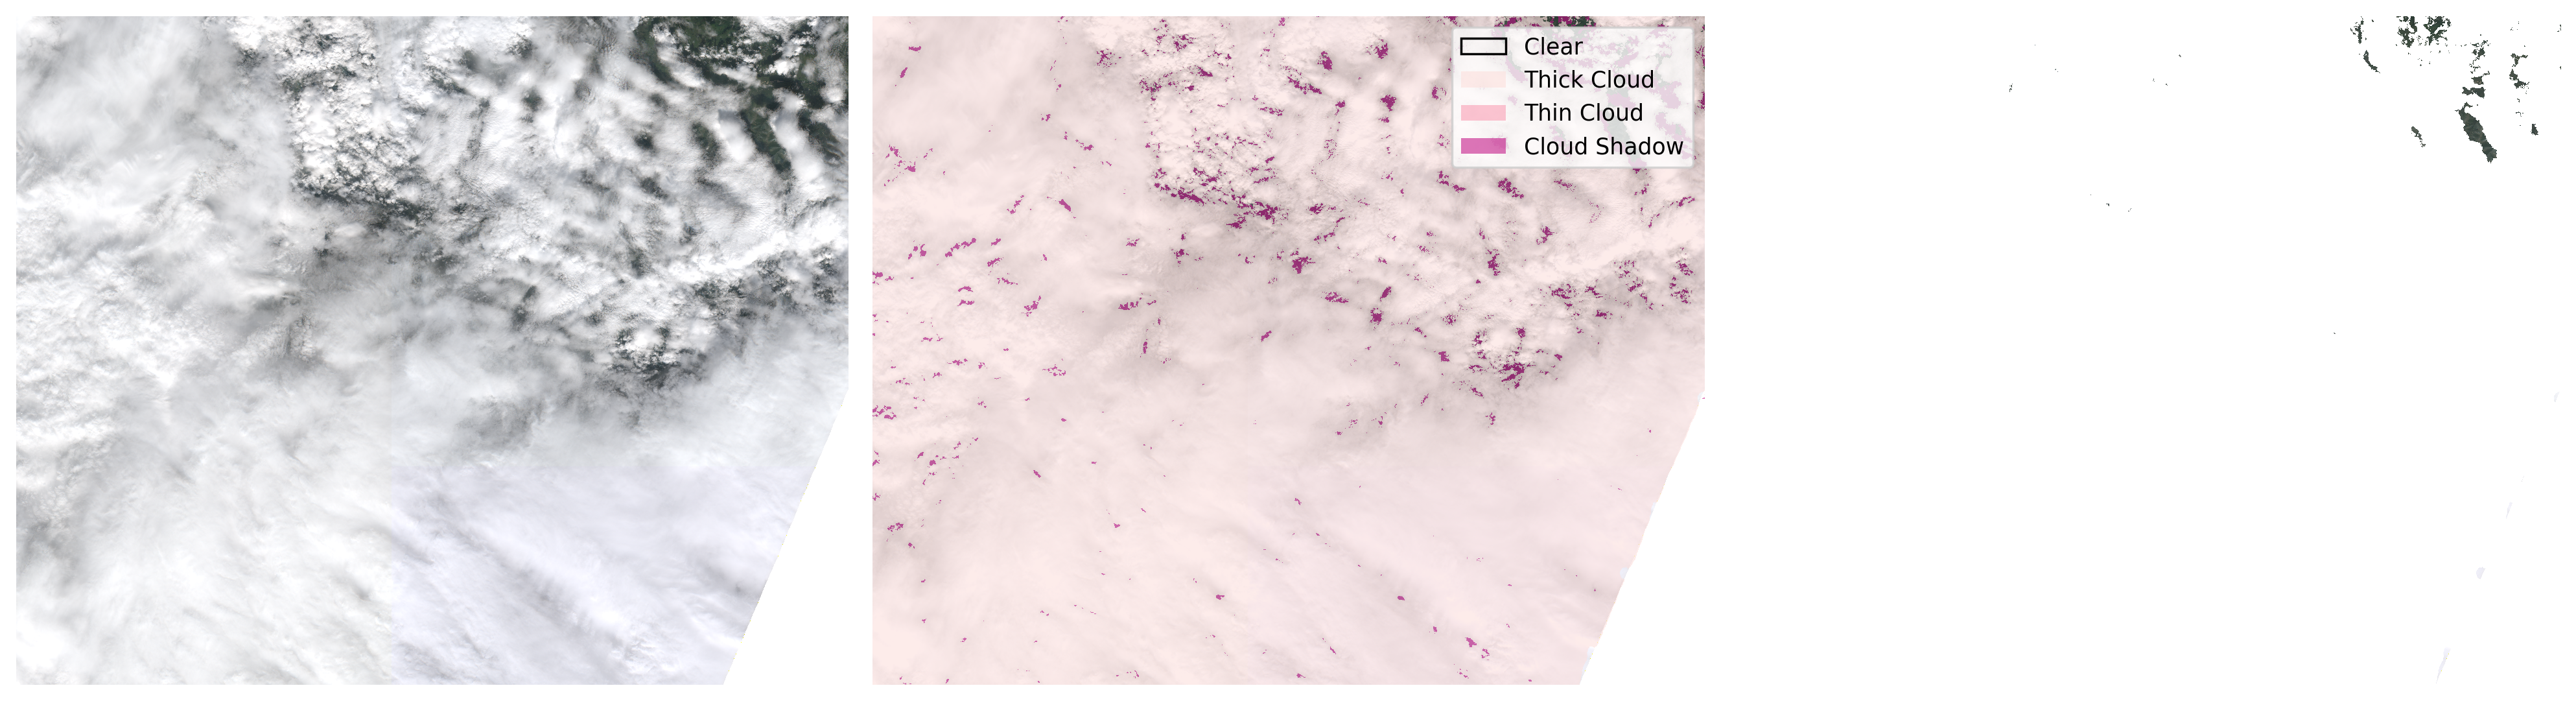

In [15]:
timestep = 100

fig, axs = plt.subplots(figsize=(16, 9), dpi=250, nrows=1, ncols=3)
ts_original = ds.isel(time=timestep).compute()
ts_cloudmasked = cloudmasked.isel(time=timestep)
ts_cloudfilled = cloud_filled.isel(time=timestep)

gamma = 2.2

(xarray.where(ts_original['rgb']<0, 0, ts_original['rgb'])**(1/gamma)).plot.imshow(ax=axs[0])
(xarray.where(ts_original['rgb']<0, 0, ts_original['rgb'])**(1/gamma)).plot.imshow(ax=axs[1])
ts_original['cloudmask'].plot.imshow(ax=axs[1], cmap=cmap, norm=norm, alpha=1, add_colorbar=False)
(xarray.where(ts_cloudfilled['rgb']<0, 0, ts_cloudfilled['rgb'])**(1/gamma)).plot.imshow(ax=axs[2])

legend_elements = [
    matplotlib.patches.Patch(facecolor='none', edgecolor='black', label='Clear'),
    matplotlib.patches.Patch(facecolor=colors[1], label='Thick Cloud'),
    matplotlib.patches.Patch(facecolor=colors[2], label='Thin Cloud'),
    matplotlib.patches.Patch(facecolor=colors[3], label='Cloud Shadow')
]
axs[1].legend(handles=legend_elements, loc='upper right')

for ax in axs:
    ax.set_aspect('equal')
    ax.axis('off')
    ax.title.set_visible(False)
fig.tight_layout()

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

print(ds['time'].isel(time=timestep).values)

In [16]:
fig.savefig('cloudfilled.png')

# Fix shade
```
ifsca=ifsca./(1-fshade-A.fice-A.cc);
ifsca(ifsca>1 | ifsca<0)=1;
```

Todo:
- [ ] Filter fsca==0 to prevent divide-by-zero

In [17]:
shade_non100  = xarray.where(cloud_filled['fshade'] == 100, np.nan, cloud_filled['fshade'])
ifsca = (cloud_filled['fsca'] / (100 - shade_non100)) * 100
ifsca = xarray.where((abs(ifsca)>100) | (ifsca<0), 100, ifsca)
ifsca = xarray.where(cloud_filled['fshade']==100, 0, ifsca)

/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 12.40 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 25.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


2018-10-01


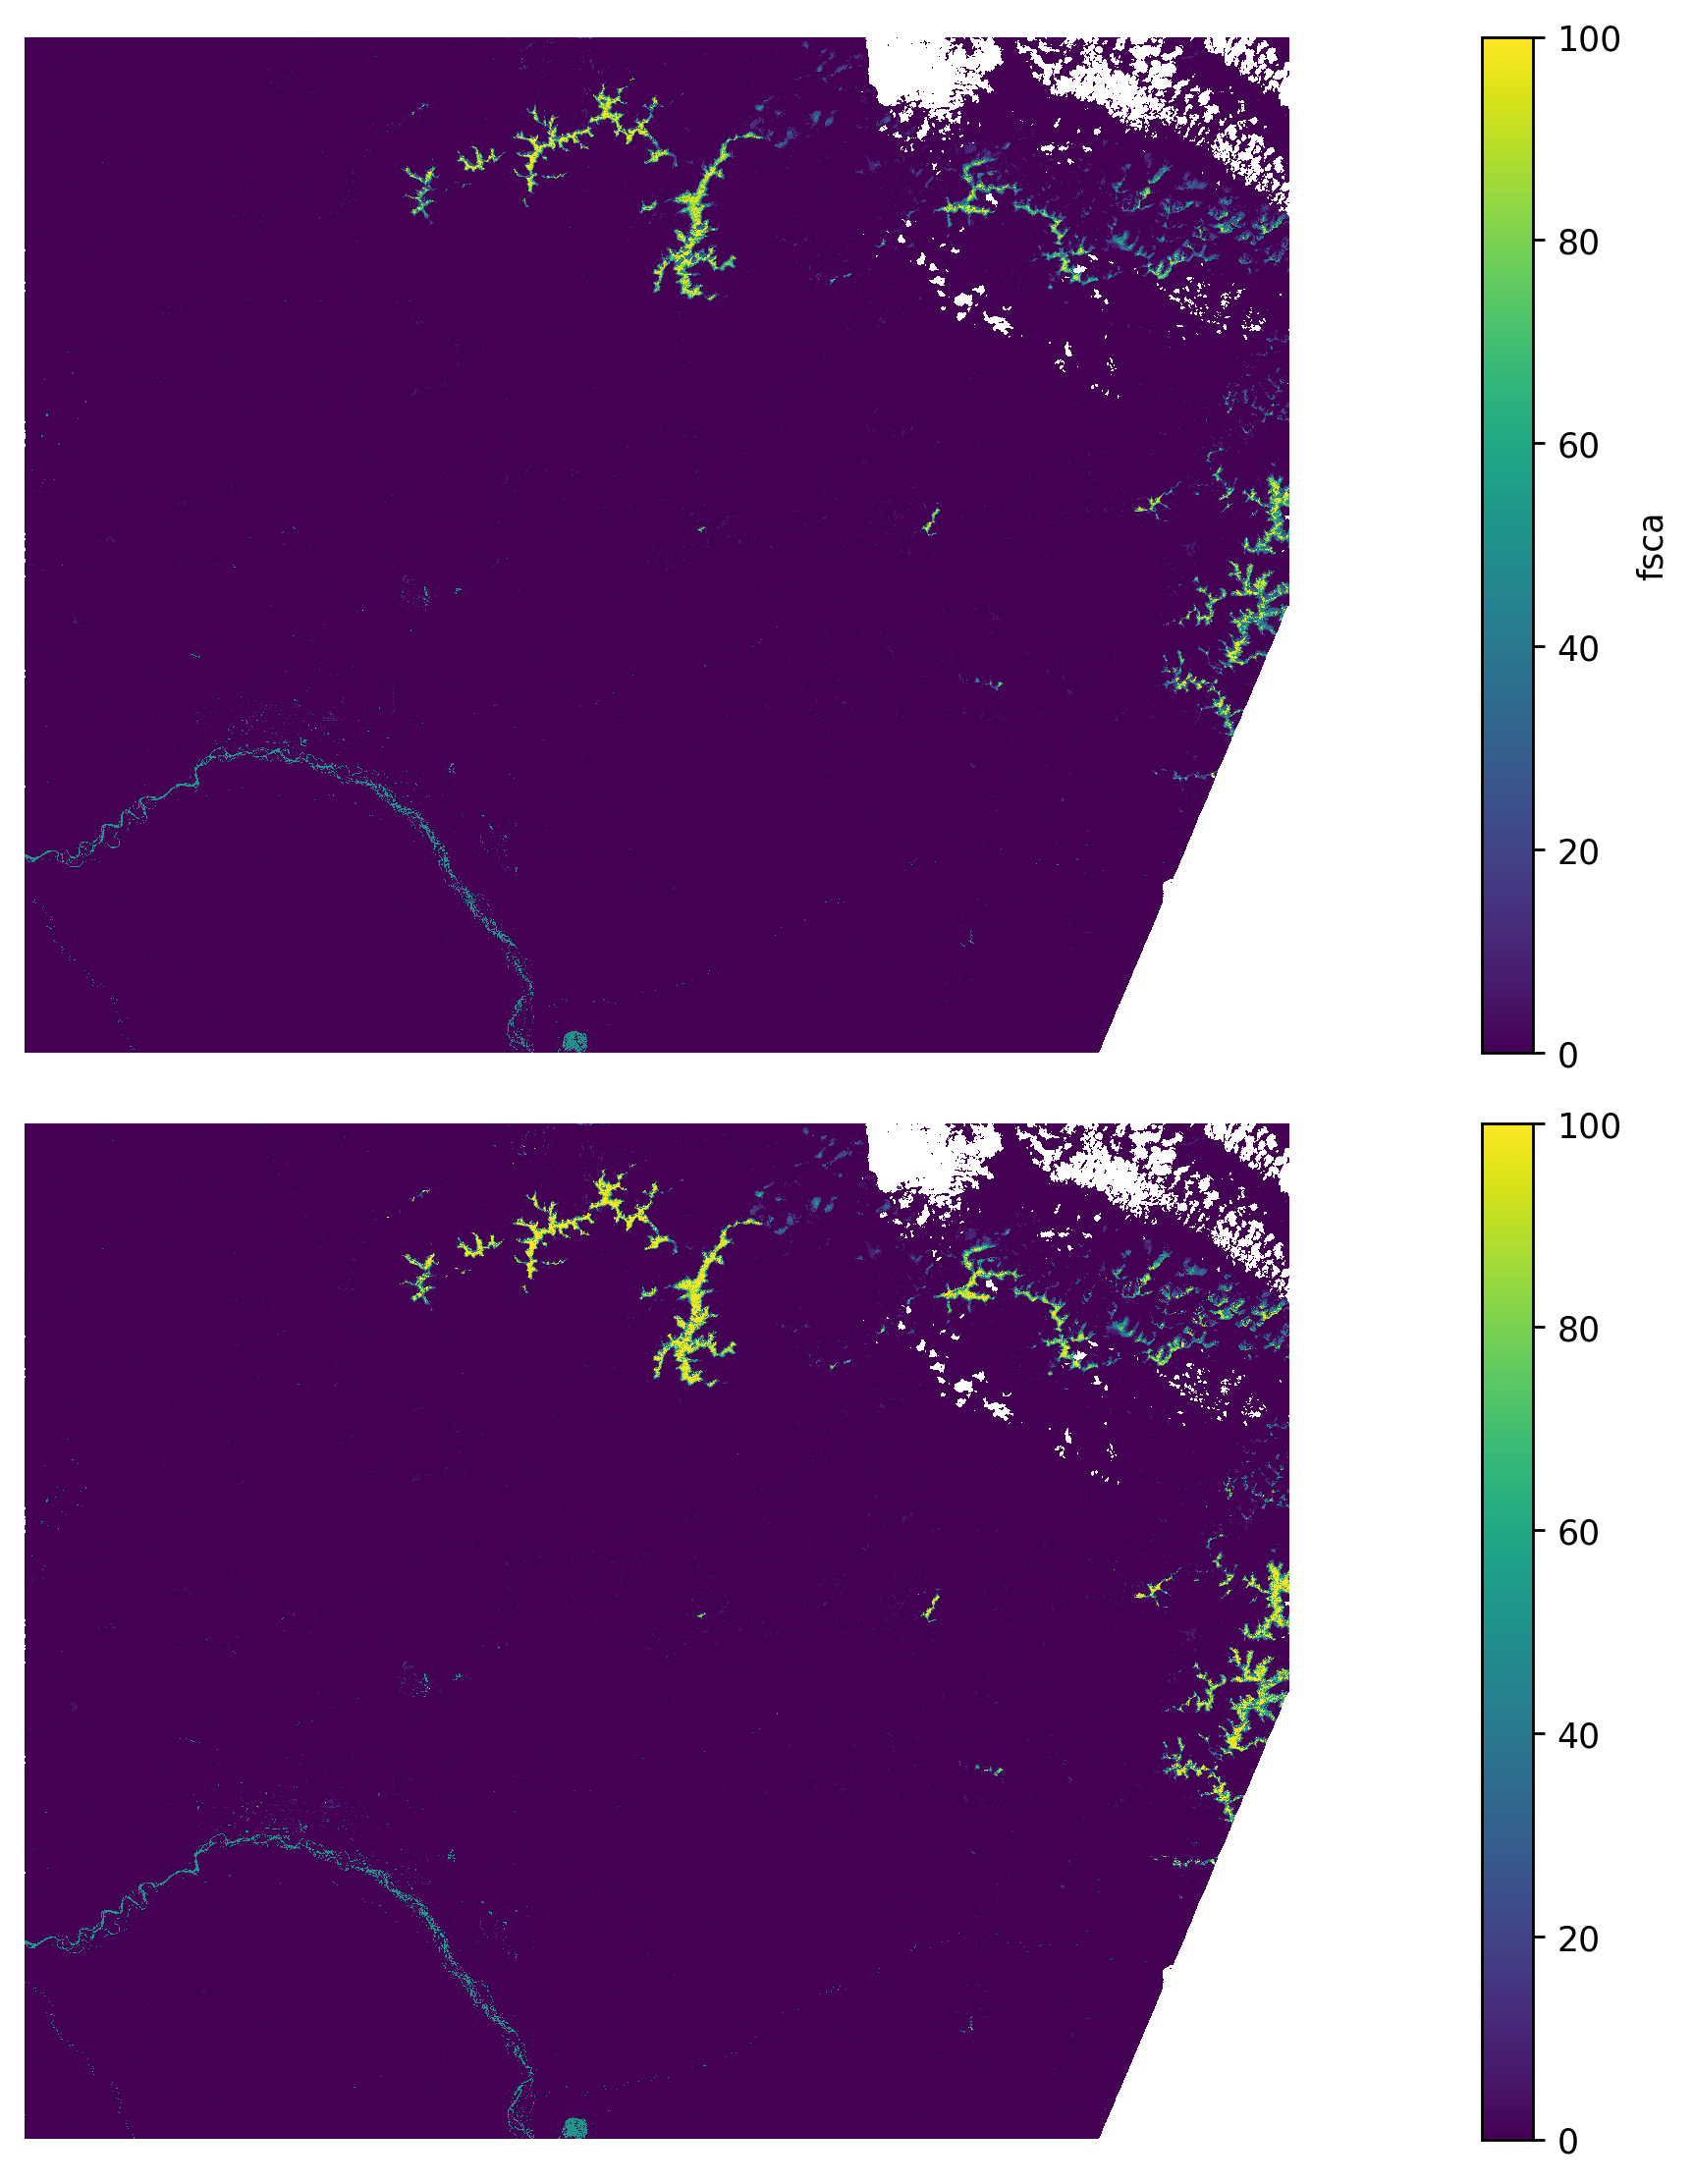

In [18]:
timestep = 111

fig, axs = plt.subplots(figsize=(16, 9), dpi=250, nrows=2)
ts_cloudfilled = cloud_filled.isel(time=timestep)

ts_cloudfilled['fsca'].plot(ax=axs[0])
ifsca.isel(time=timestep).plot(ax=axs[1])
    
for ax in axs:
    ax.set_aspect('equal')
    ax.axis('off')
    ax.title.set_visible(False)
fig.tight_layout()

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

date = ds['time'].isel(time=timestep).dt.strftime('%Y-%m-%d').values
print(date)

In [19]:
cloud_filled['fsca'] = ifsca

# Type conversion

In [20]:
fill_value = -1

In [21]:
cloud_filled['fsca'] = xarray.where(np.isnan(cloud_filled['fsca']), fill_value, cloud_filled['fsca']).astype(np.int8)
cloud_filled['fshade'] = xarray.where(np.isnan(cloud_filled['fshade']), fill_value, cloud_filled['fshade']).astype(np.int8)

In [22]:
cloud_filled['fsca'].attrs["_FillValue"] = fill_value
cloud_filled['fshade'].attrs["_FillValue"] = fill_value

In [23]:
cloud_filled

<xarray.Dataset> Size: 3TB
Dimensions:             (y: 14628, time: 463, x: 18208, band: 3)
Coordinates:
  * y                   (y) float64 117kB 7.289e+06 7.289e+06 ... 7.142e+06
  * time                (time) datetime64[ns] 4kB 2015-10-22 ... 2025-03-13
  * x                   (x) float64 146kB 4.277e+05 4.277e+05 ... 6.098e+05
  * band                (band) object 24B 'B4' 'B3' 'B2'
Data variables:
    fsca                (time, y, x) int8 123GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    fshade              (time, y, x) int8 123GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    grain_size          (time, y, x) float32 493GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    dust_concentration  (time, y, x) float32 493GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    rgb                 (time, y, x, band) float32 1TB dask.array<chunksize=(1, 1219, 1138, 3), meta=np.ndarray>
    spatial_ref         int64 8B ...

# Store

In [24]:
%%time
path = f'{prefix}/{region}_postprocessed.zarr'
cloud_filled.to_zarr(path, mode='w', consolidated=False)

/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 105.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-06-07 12:12:11,714 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:42101
Traceback (most recent call last):
  File "/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/home/griessban/.conda/envs/cloud/lib/python3.13/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connec

CPU times: user 1h 49min 59s, sys: 28min 39s, total: 2h 18min 38s
Wall time: 9h 54min 32s


In [25]:
client.close()
cluster.close()

In [26]:
1

1